# 06 — RO2 evaluation (correlation + cohort ANOVA)

**Inputs:**
- `artefacts/clean_events.parquet` (engaged cohort, ping-free).
- `artefacts/cohort_engaged.parquet`.
- `artefacts/segments.parquet` (lecture-level proxies).
- `artefacts/cell_occupancy.parquet` (cell-level proxies, calibration set only).

**Outputs:**
- `artefacts/features_user_lecture.parquet`.
- `artefacts/ro2_correlations.csv`.
- `artefacts/ro2_anova.json`.
- Correlation-matrix figure + Tukey HSD pairwise plot.

In [1]:
from pathlib import Path
import json
import numpy as np, pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
OUT = Path('artefacts')
FIG = OUT / 'figures'; FIG.mkdir(exist_ok=True, parents=True)

events = pd.read_parquet(OUT / 'clean_events.parquet')
cohort = pd.read_parquet(OUT / 'cohort_engaged.parquet')
segments = pd.read_parquet(OUT / 'segments.parquet')
occupancy = pd.read_parquet(OUT / 'cell_occupancy.parquet')
print(f'events:  {len(events):,}')
print(f'cohort:  {len(cohort)}')
print(f'segments:{len(segments):,}')
print(f'cell occupancy rows: {len(occupancy):,} (calibration lectures only)')

events:  146,118
cohort:  405
segments:906
cell occupancy rows: 18 (calibration lectures only)


## Build per-(registration, lecture) feature matrix

In [2]:
import re

# Build a matching key by stripping the chapter prefix from segments.lecture_id (e.g. "05-bananovy-klavir" → "bananovy-klavir").
strip_prefix = lambda s: re.sub(r'^\d+-', '', s)

ev = events.copy()
ev['match_slug'] = ev.lecture_slug

seg = segments.copy()
seg['match_slug'] = seg.lecture_id.map(strip_prefix)

occ = occupancy.copy()
occ['match_slug'] = occ.lecture_id.map(strip_prefix)

# Per-(reg, course, lecture) event counts.
lec_dur = ev.groupby(['course_id','match_slug']).lecture_video_duration.first().reset_index()

wide = (
    ev.groupby(['registration_id','course_id','match_slug','lecture_video_duration'])
      .action_type.value_counts().unstack(fill_value=0).reset_index()
)
for col in ['play','pause','rewind','advance','end','playback','text_track']:
    if col not in wide.columns:
        wide[col] = 0
wide = wide.rename(columns={'play':'n_play','pause':'n_pause','rewind':'n_rewind',
                            'advance':'n_advance','end':'n_end'})
wide['rate_pause']  = wide.n_pause  / wide.lecture_video_duration
wide['rate_rewind'] = wide.n_rewind / wide.lecture_video_duration
wide['any_pause']   = (wide.n_pause  > 0).astype(int)
wide['any_rewind']  = (wide.n_rewind > 0).astype(int)

# Lecture-level semantic proxies from segments.
def lecture_proxies(seg_df):
    s = seg_df.sort_values('segment_idx')
    word_count = s.text.str.split().apply(len).sum()
    n_segments = len(s)
    embs = np.stack(s.embedding.tolist())
    if len(embs) >= 2:
        from sklearn.metrics.pairwise import cosine_similarity
        sim_pairs = [cosine_similarity(embs[i:i+1], embs[i-1:i])[0,0] for i in range(1, len(embs))]
        mean_novelty = 1.0 - float(np.mean(sim_pairs))
        centroid = embs.mean(axis=0, keepdims=True)
        drifts = cosine_similarity(embs, centroid).flatten()
        mean_topic_shift = float(drifts.std())
    else:
        mean_novelty = 0.0
        mean_topic_shift = 0.0
    return pd.Series({
        'total_words':      int(word_count),
        'n_segments':       n_segments,
        'mean_novelty':     mean_novelty,
        'mean_topic_shift': mean_topic_shift,
    })

proxies = (
    seg.groupby(['course_id','match_slug'])
       .apply(lecture_proxies, include_groups=False)
       .reset_index()
)
wide = wide.merge(proxies, on=['course_id','match_slug'], how='left')

# Cell-level proxies (only for calibration lectures).
cell_lec = (
    occ.assign(is_high_bloom=lambda d: (d.cognitive_process >= 3).astype(int))
       .groupby(['course_id','match_slug']).apply(
           lambda g: pd.Series({
               'n_los_bloom_ge3': int((g['count'] * g.is_high_bloom).sum()),
           }),
           include_groups=False,
       ).reset_index()
)
wide = wide.merge(cell_lec, on=['course_id','match_slug'], how='left')

wide.to_parquet(OUT / 'features_user_lecture.parquet', index=False)
print(f'feature matrix: {wide.shape}')
print(f'reg-lec pairs with proxies: {wide.mean_novelty.notna().sum()}')
print(f'reg-lec pairs with cell-level proxies: {wide.n_los_bloom_ge3.notna().sum()}')

feature matrix: (8965, 20)
reg-lec pairs with proxies: 8886
reg-lec pairs with cell-level proxies: 298


## RO2.1 — Correlation between event density and content complexity

In [3]:
# log(1+x) on rate features.
for c in ['rate_pause','rate_rewind']:
    wide[f'log1p_{c}'] = np.log1p(wide[c])

EVENT_COLS = ['log1p_rate_pause','log1p_rate_rewind']
PROXY_COLS = ['mean_novelty','mean_topic_shift','total_words','n_segments']
CELL_COLS  = ['n_los_bloom_ge3']

rows = []
for ev_col in EVENT_COLS:
    for px_col in PROXY_COLS + CELL_COLS:
        sub = wide[[ev_col, px_col]].dropna()
        if len(sub) < 30 or sub[px_col].nunique() < 2:
            continue
        if sub[px_col].nunique() == 2:
            r, p = stats.pointbiserialr(sub[px_col], sub[ev_col])
            test = 'point-biserial'
        else:
            r, p = stats.pearsonr(sub[ev_col], sub[px_col])
            test = 'pearson'
        rows.append({'event': ev_col, 'proxy': px_col, 'test': test, 'r': r, 'p': p, 'n': len(sub)})
        rs, ps = stats.spearmanr(sub[ev_col], sub[px_col])
        rows.append({'event': ev_col, 'proxy': px_col, 'test': 'spearman', 'r': rs, 'p': ps, 'n': len(sub)})

corr = pd.DataFrame(rows)
_, holm_p, _, _ = multipletests(corr.p.values, method='holm')
corr['p_holm'] = holm_p
corr['H1_met'] = (corr['p_holm'] < 0.05) & (corr['r'].abs() >= 0.10)
corr.to_csv(OUT / 'ro2_correlations.csv', index=False)
print(corr.sort_values('p_holm').round(4).to_string(index=False))

            event            proxy     test       r      p    n  p_holm  H1_met
 log1p_rate_pause      total_words spearman -0.1910 0.0000 8886  0.0000    True
 log1p_rate_pause       n_segments spearman -0.1907 0.0000 8886  0.0000    True
 log1p_rate_pause     mean_novelty  pearson -0.1283 0.0000 8886  0.0000    True
log1p_rate_rewind      total_words spearman  0.1182 0.0000 8886  0.0000    True
 log1p_rate_pause      total_words  pearson -0.1156 0.0000 8886  0.0000    True
 log1p_rate_pause mean_topic_shift spearman -0.1155 0.0000 8886  0.0000    True
 log1p_rate_pause       n_segments  pearson -0.1118 0.0000 8886  0.0000    True
log1p_rate_rewind       n_segments spearman  0.1109 0.0000 8886  0.0000    True
log1p_rate_rewind mean_topic_shift spearman  0.1056 0.0000 8886  0.0000    True
 log1p_rate_pause mean_topic_shift  pearson -0.0671 0.0000 8886  0.0000   False
 log1p_rate_pause     mean_novelty spearman -0.0636 0.0000 8886  0.0000   False
log1p_rate_rewind       n_segments  pear

### Correlation matrix figure

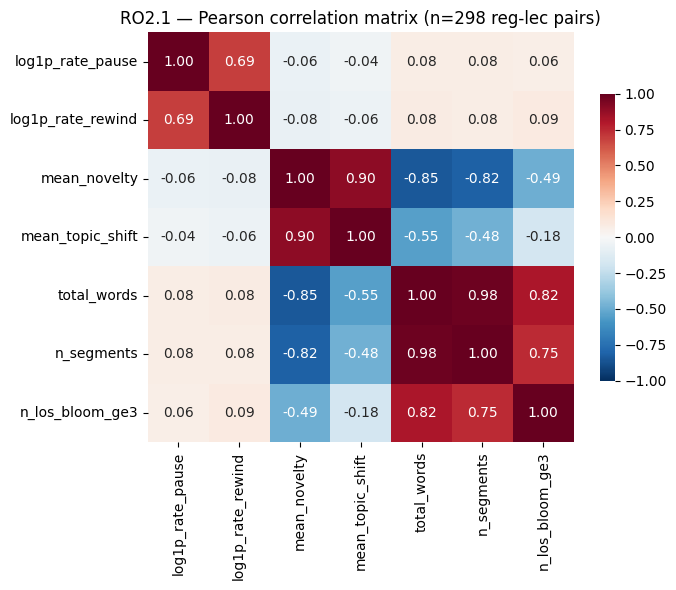

In [4]:
feats = wide[EVENT_COLS + PROXY_COLS + CELL_COLS].dropna()
corr_mat = feats.corr(method='pearson')
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title(f'RO2.1 — Pearson correlation matrix (n={len(feats):,} reg-lec pairs)')
fig.tight_layout()
fig.savefig(FIG / 'correlation_matrix.png', dpi=150)
plt.show()

## RO2.2 — Cohort ANOVA + Tukey HSD

In [5]:
df = wide[['course_id','log1p_rate_pause','log1p_rate_rewind']].dropna()
df['course'] = df.course_id.astype(str)

# Assumption checks.
groups = [g['log1p_rate_pause'].values for _, g in df.groupby('course')]
lev_stat, lev_p = stats.levene(*groups, center='median')
print(f'Levene W={lev_stat:.3f}, p={lev_p:.2e}')

f_stat, p_anova = stats.f_oneway(*groups)
print(f'one-way ANOVA F={f_stat:.3f}, p={p_anova:.2e}')

# Welch (always reported for robustness).
model_welch = ols('log1p_rate_pause ~ C(course)', data=df).fit()
from statsmodels.stats.anova import anova_lm
welch = anova_lm(model_welch, typ=2)
print(f'Welch ANOVA (typ II):\n{welch}')

# η² (between-group SS / total SS).
ss_between = welch.loc['C(course)', 'sum_sq']
ss_total   = welch['sum_sq'].sum()
eta2 = ss_between / ss_total
print(f'η² = {eta2:.4f}')

tukey = pairwise_tukeyhsd(df.log1p_rate_pause.values, df.course.values, alpha=0.05)
print('\nTukey HSD:')
print(tukey)

tukey_df = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])

summary = {
    'n_pairs':     int(len(df)),
    'levene_W':    round(float(lev_stat), 3),
    'levene_p':    float(lev_p),
    'anova_F':     round(float(f_stat), 3),
    'anova_p':     float(p_anova),
    'eta_squared': round(float(eta2), 4),
    'reject_h0':   bool(p_anova < 0.05),
}
pd.DataFrame([summary]).to_csv(OUT / 'ro2_anova_summary.csv', index=False)
tukey_df.to_csv(OUT / 'ro2_tukey_pairs.csv', index=False)
print('wrote ro2_anova_summary.csv and ro2_tukey_pairs.csv')
print(summary)

Levene W=14.454, p=9.10e-12
one-way ANOVA F=16.942, p=7.58e-14
Welch ANOVA (typ II):
             sum_sq      df          F        PR(>F)
C(course)  0.029370     4.0  16.941605  7.577319e-14
Residual   3.883216  8960.0        NaN           NaN
η² = 0.0075



Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1     30  -0.0045    0.0 -0.0063 -0.0028   True
     1     32  -0.0042    0.0 -0.0061 -0.0022   True
     1     42  -0.0018 0.0423 -0.0035    -0.0   True
     1      5  -0.0039    0.0 -0.0059 -0.0018   True
    30     32   0.0004  0.987 -0.0016  0.0023  False
    30     42   0.0027 0.0002   0.001  0.0045   True
    30      5   0.0006 0.9191 -0.0014  0.0027  False
    32     42   0.0024 0.0081  0.0004  0.0043   True
    32      5   0.0003 0.9973  -0.002  0.0025  False
    42      5  -0.0021 0.0442 -0.0042    -0.0   True
----------------------------------------------------
wrote ro2_anova_summary.csv and ro2_tukey_pairs.csv
{'n_pairs': 8965, 'levene_W': 14.454, 'levene_p': 9.102400830164486e-12, 'anova_F': 16.942, 'anova_p': 7.577318674261352e-14, 'eta_squared': 0.0075, 'reject_h0': True}


### Tukey HSD pairwise figure

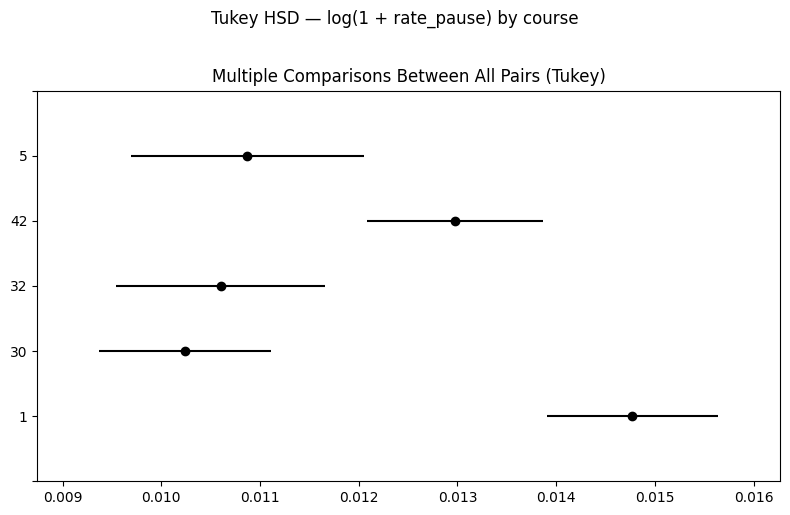

In [6]:
fig = tukey.plot_simultaneous(figsize=(8, 5))
fig.suptitle('Tukey HSD — log(1 + rate_pause) by course', y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'tukey_pairwise.png', dpi=150, bbox_inches='tight')
plt.show()